这里说频率是指一个机场航班出现的频率

## 加载数据

数据已经预处理过了

In [1]:
import pandas as pd

# 加载数据
data = pd.read_csv('../../data-hh/my/hh_result/result_all.csv', dtype={'aircraft': str})

# 查看前几行数据，确保加载成功
print(data.head())

print(data.info())

         flt_no bd_type    cap aircraft  legs  leg_no  duration  pax  \
0  KgJrsp7Jd78=      窄体  132.0      319     1       1      1.07   25   
1  P9IRwar34h0=      窄体  189.0      321     1       1      1.38  151   
2  mJitm0UDfM4=      窄体  132.0      319     1       1      1.57   38   
3  jXr97M1wpn4=      窄体  132.0      319     1       1      1.58  109   
4  izjfHOxAho4=      窄体  132.0      319     1       1      1.80  124   

              a             b  ...  year  month  day  weekday  hour  minute  \
0  KNqX4/Q5Noc=  HexFWXqbb8I=  ...  2023     10    1        6    12      15   
1  AKQNtuL5r6Q=  Mv6HkAiSLUk=  ...  2023     10    1        6    20      10   
2  n465JzB8Rrw=  N4hmDZN/CJQ=  ...  2023     10    1        6    16      45   
3  N4hmDZN/CJQ=  n465JzB8Rrw=  ...  2023     10    1        6    19      40   
4  5t+HPO9Mu/w=  X5e5r3CS4OA=  ...  2023     10    1        6    13       5   

   second          from            to   unit_price  
0       0  KNqX4/Q5Noc=  HexFWXqbb8I=  

## 编码分类变量

### 新增城市标签

In [2]:
# 加载字典
with open('../../data-hh/my/encoder/city_labels_总客流加权图标签.json', 'r') as file:
    city_labels_loaded = json.load(file)

print("加载的字典：", city_labels_loaded)

加载的字典： {'KNqX4/Q5Noc=': 1, 'HexFWXqbb8I=': 1, 'AKQNtuL5r6Q=': 1, 'Mv6HkAiSLUk=': 1, 'n465JzB8Rrw=': 1, 'N4hmDZN/CJQ=': 1, '5t+HPO9Mu/w=': 0, 'X5e5r3CS4OA=': 1, 'EF9aodHSh3E=': 1, 'iX2Pe2pxiqQ=': 0, 'lrbLyY7nRiw=': 1, 'vbo2dwBOeps=': 1, 'fl/vmiIcdls=': 1, 'a2cXIUGpIbw=': 1, 'Ne7JZ9C2ayc=': 1, 'XUXDuFGVfBM=': 2, 'tKjndGSl9NQ=': 1, 'xIqe+QQIQXQ=': 1, 'RTA+2OkM90I=': 1, 'KETr2NAmAHE=': 1, 'OJ0BsQ7KlKk=': 1, 'So/c8CkA/Xs=': 1, 'Lue5PP9SfQU=': 1, 'h9GisD/ZayE=': 1, 'zwVGiYamVc0=': 1, '/qxKZMQeBus=': 1, 'DUbxF00Y8a0=': 1, 'Y50ETJ8qYSE=': 1, 'QyEgIt0M8Sg=': 1, 'xRL77yJN1tk=': 1, 'hwin1ipuzwk=': 1, 'CnmNtb5MOJA=': 1, '9j4ofoSZvc4=': 1, 'Qe7TEMbQt6o=': 1, 'tiwC3iWlaiU=': 0, 'g1hKMyP1V8I=': 1, '/M8gHzjxpNU=': 1, 'wSF4qXvI044=': 1, 'grkgazDvJmY=': 1, 'AfKac4FzdXs=': 1, 'yypkiQCX5lk=': 1, 'qjPVpekqsPo=': 1, 'FWD6O2fHsIU=': 1, '4Liydpz6+ug=': 1, '1/9nd1jNCE0=': 1, '4jcxTvZ+J1A=': 1, 'y+pJ91YLvhA=': 1, '2WRfpdopfDw=': 1, '81MA7ppp7mI=': 1, 'gK3uAaRHrOs=': 1, 'KFsTKxkC/6g=': 1, 'XuLAnICDnIM=': 1, '+O1

In [3]:
# 使用 map 对 'a', 'b', 'c', 'from', 'to' 列进行标签化，新增对应的标签列
data['a_label'] = data['a'].map(city_labels_loaded)
data['b_label'] = data['b'].map(city_labels_loaded)
data['c_label'] = data['c'].map(city_labels_loaded)
data['from_label'] = data['from'].map(city_labels_loaded)
data['to_label'] = data['to'].map(city_labels_loaded)

### 新增城市二维嵌入

In [4]:
import json

# 加载字典
with open('../../data-hh/my/encoder/城市嵌入编码_总客流加权图', 'r') as file:
    city_embeddings = json.load(file)

print("加载的字典：", city_embeddings)


加载的字典： {'KNqX4/Q5Noc=': [-0.30124732851982117, -0.29528331756591797], 'HexFWXqbb8I=': [0.6225460767745972, -0.0579943023622036], 'AKQNtuL5r6Q=': [-0.21069030463695526, -1.019451379776001], 'Mv6HkAiSLUk=': [-0.3282053470611572, -0.3431733250617981], 'n465JzB8Rrw=': [0.5361536145210266, -0.13385199010372162], 'N4hmDZN/CJQ=': [0.01228764932602644, -1.0385137796401978], '5t+HPO9Mu/w=': [0.735469400882721, -0.7177906036376953], 'X5e5r3CS4OA=': [0.0628906860947609, -0.45157182216644287], 'EF9aodHSh3E=': [-0.3087059259414673, -0.7854071259498596], 'iX2Pe2pxiqQ=': [0.5242692232131958, -0.5245727896690369], 'lrbLyY7nRiw=': [-0.3287799656391144, -0.36911284923553467], 'vbo2dwBOeps=': [-0.44242605566978455, -0.8875601291656494], 'fl/vmiIcdls=': [-0.08861442655324936, -0.2671923339366913], 'a2cXIUGpIbw=': [-0.12381066381931305, -0.9250358939170837], 'Ne7JZ9C2ayc=': [0.026035215705633163, 0.03381938114762306], 'XUXDuFGVfBM=': [1.1213572025299072, -1.1232333183288574], 'tKjndGSl9NQ=': [-0.3204067349

In [5]:
import pandas as pd
import numpy as np

# 将 city_embeddings 转换为 DataFrame
embedding_df = pd.DataFrame.from_dict(city_embeddings, orient='index', columns=['embedding_1', 'embedding_2'])
embedding_df.index.name = 'city'

# 用 'a', 'b', 'c', 'from', 'to' 字段与 embedding_df 合并
data = data.merge(embedding_df, left_on='a', right_index=True, how='left')
data.rename(columns={'embedding_1': 'a_embedding_1', 'embedding_2': 'a_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='b', right_index=True, how='left')
data.rename(columns={'embedding_1': 'b_embedding_1', 'embedding_2': 'b_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='c', right_index=True, how='left')
data.rename(columns={'embedding_1': 'c_embedding_1', 'embedding_2': 'c_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='from', right_index=True, how='left')
data.rename(columns={'embedding_1': 'from_embedding_1', 'embedding_2': 'from_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='to', right_index=True, how='left')
data.rename(columns={'embedding_1': 'to_embedding_1', 'embedding_2': 'to_embedding_2'}, inplace=True)

# 查看添加的新列
print(data[['a_embedding_1', 'a_embedding_2', 'b_embedding_1', 'b_embedding_2', 'c_embedding_1', 'c_embedding_2', 'from_embedding_1', 'from_embedding_2', 'to_embedding_1', 'to_embedding_2']])


         a_embedding_1  a_embedding_2  b_embedding_1  b_embedding_2  \
0            -0.301247      -0.295283       0.622546      -0.057994   
1            -0.210690      -1.019451      -0.328205      -0.343173   
2             0.536154      -0.133852       0.012288      -1.038514   
3             0.012288      -1.038514       0.536154      -0.133852   
4             0.735469      -0.717791       0.062891      -0.451572   
...                ...            ...            ...            ...   
5999220      -0.425696      -0.908476      -0.442426      -0.887560   
5999221      -0.442426      -0.887560      -0.425696      -0.908476   
5999222      -0.425696      -0.908476      -0.442426      -0.887560   
5999223      -0.442426      -0.887560      -0.327313       0.064449   
5999224      -0.327313       0.064449      -0.442426      -0.887560   

         c_embedding_1  c_embedding_2  from_embedding_1  from_embedding_2  \
0                  NaN            NaN         -0.301247         -0.295

### 统计不同城市的频率

In [6]:
# 将 from 和 to 两列合并，并统计每个城市的出现次数
city_count_series = pd.concat([data['from'], data['to']]).value_counts()

# 转换为 city_count 数据框
city_count = city_count_series.reset_index()
city_count.columns = ['city', 'count']

# 3. 创建 city_map，将每个城市映射为其出现次数（或者任何你需要的值）
city_map = dict(zip(city_count['city'], city_count['count']))

# 输出结果
print(city_count)

             city   count
0    vbo2dwBOeps=  478332
1    /M8gHzjxpNU=  450316
2    gK3uAaRHrOs=  446006
3    So/c8CkA/Xs=  418933
4    0J4jz5aCatU=  408305
..            ...     ...
247  iPk6Y04ZgnI=     122
248  MgrS1LT2KO4=      91
249  DwCmftDLjPw=      62
250  wbf1sxPhwNM=      60
251  Eed3EdkMDqg=      49

[252 rows x 2 columns]


使用 json 保存和加载 city_map

In [7]:
import json

# 保存 city_map 到 JSON 文件
with open('../../data-hh/my/encoder/city_map_频率编码.json', 'w') as f:
    json.dump(city_map, f)

print("city_map_频率编码 已保存到 city_map_频率编码")

city_map_频率编码 已保存到 city_map_频率编码


In [8]:
# 使用 city_map 替换指定列的值
columns_to_replace = ['a', 'b', 'c', 'from', 'to']

# 遍历指定列并直接用 map 映射
for col in columns_to_replace:
    data[col] = data[col].map(city_map)

# 输出结果
print(city_count)
print(data)

             city   count
0    vbo2dwBOeps=  478332
1    /M8gHzjxpNU=  450316
2    gK3uAaRHrOs=  446006
3    So/c8CkA/Xs=  418933
4    0J4jz5aCatU=  408305
..            ...     ...
247  iPk6Y04ZgnI=     122
248  MgrS1LT2KO4=      91
249  DwCmftDLjPw=      62
250  wbf1sxPhwNM=      60
251  Eed3EdkMDqg=      49

[252 rows x 2 columns]
               flt_no bd_type    cap aircraft  legs  leg_no  duration  pax  \
0        KgJrsp7Jd78=      窄体  132.0      319     1       1      1.07   25   
1        P9IRwar34h0=      窄体  189.0      321     1       1      1.38  151   
2        mJitm0UDfM4=      窄体  132.0      319     1       1      1.57   38   
3        jXr97M1wpn4=      窄体  132.0      319     1       1      1.58  109   
4        izjfHOxAho4=      窄体  132.0      319     1       1      1.80  124   
...               ...     ...    ...      ...   ...     ...       ...  ...   
5999220  BzUm4im0EqA=      窄体  152.0      320     1       1      3.03   99   
5999221  w+GXbx7u3EM=      窄体  152.0    

In [9]:
import joblib
from sklearn.preprocessing import LabelEncoder
import os

# 定义需要编码的分类特征
# categorical_columns = ['flt_no', 'bd_type', 'aircraft', 'a', 'b', 'c', 'from', 'to']
categorical_columns = ['flt_no', 'bd_type', 'aircraft']

# 创建并应用 LabelEncoder
label_encoders = {}

# 创建保存编码器的文件夹（如果文件夹不存在）
save_folder = '../../data-hh/my/encoder/'
os.makedirs(save_folder, exist_ok=True)  # 如果文件夹已存在，不会报错

# 遍历每个分类特征，使用 LabelEncoder 对其进行编码
for col in categorical_columns:
    le = LabelEncoder()  # 创建一个 LabelEncoder 实例
    data[col] = le.fit_transform(data[col])  # 对训练数据中的分类特征进行编码
    label_encoders[col] = le  # 将每个特征的编码器保存到字典中，方便后续使用

    # 保存每个编码器到指定文件夹
    encoder_path = os.path.join(save_folder, f"{col}_encoder_all.pkl")  # 构建保存路径
    joblib.dump(le, encoder_path)  # 使用 joblib 将编码器保存为 pkl 文件
    print(f"{col} 的编码器已保存为 {encoder_path}")  # 输出保存的路径

flt_no 的编码器已保存为 ../../data-hh/my/encoder/flt_no_encoder_all.pkl
bd_type 的编码器已保存为 ../../data-hh/my/encoder/bd_type_encoder_all.pkl
aircraft 的编码器已保存为 ../../data-hh/my/encoder/aircraft_encoder_all.pkl


## 特征和目标分离
我们要预测的是pax字段，其他字段作为特征。

In [10]:
# 特征列
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft',  'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','holiday', 'hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label']]

# 有abc，有标签，有嵌入
X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 删除了abc，但有标签，有嵌入
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 目标列
y = data['pax']

## 训练XGBoost模型

In [11]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 自定义 SMAPE 函数
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    return np.mean(diff / denominator) * 100

# 自定义评估函数
def smape_eval(y_pred, dtrain):
    y_true = dtrain.get_label()
    smape_value = smape(y_true, y_pred)
    return 'SMAPE', smape_value

# 数据划分
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 输出数据集大小
print(f'训练集大小: {X_train.shape[0]}')
print(f'验证集大小: {X_val.shape[0]}')
print(f'测试集大小: {X_test.shape[0]}')

# 转换为 DMatrix 格式
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# 设置参数
params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'alpha': 10
}

# 设置评估集
evals = [(dtrain, 'train'), (dval, 'validation')]

# 训练模型，使用自定义评估指标
model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=10,
    custom_metric=smape_eval,  # 使用 custom_metric 参数
    verbose_eval=10 #隔多少轮显示一次
)

# 预测测试集
y_pred = model.predict(dtest)

# 测试集 SMAPE 评估
test_smape = smape(y_test, y_pred)
print(f'SMAPE on Test Set: {test_smape:.2f}%')

# 测试集 MSE 评估
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error on Test Set: {mse}')


训练集大小: 4799380
验证集大小: 599922
测试集大小: 599923
[0]	train-rmse:45.26704	train-SMAPE:35.69073	validation-rmse:45.28581	validation-SMAPE:35.70263
[10]	train-rmse:42.86108	train-SMAPE:34.22098	validation-rmse:42.88450	validation-SMAPE:34.23649
[20]	train-rmse:40.70525	train-SMAPE:32.86280	validation-rmse:40.73292	validation-SMAPE:32.88071
[30]	train-rmse:38.90248	train-SMAPE:31.68258	validation-rmse:38.93370	validation-SMAPE:31.70281
[40]	train-rmse:37.27532	train-SMAPE:30.59042	validation-rmse:37.30990	validation-SMAPE:30.61200
[50]	train-rmse:35.87198	train-SMAPE:29.61136	validation-rmse:35.90974	validation-SMAPE:29.63396
[60]	train-rmse:34.66370	train-SMAPE:28.73951	validation-rmse:34.70392	validation-SMAPE:28.76232
[70]	train-rmse:33.62512	train-SMAPE:27.95680	validation-rmse:33.66757	validation-SMAPE:27.97989
[80]	train-rmse:32.75567	train-SMAPE:27.25840	validation-rmse:32.79974	validation-SMAPE:27.28178
[90]	train-rmse:32.01600	train-SMAPE:26.65370	validation-rmse:32.06157	validation-SMA

[840]	train-rmse:25.93309	train-SMAPE:20.88951	validation-rmse:25.99587	validation-SMAPE:20.91101
[850]	train-rmse:25.91906	train-SMAPE:20.87807	validation-rmse:25.98189	validation-SMAPE:20.89963
[860]	train-rmse:25.90420	train-SMAPE:20.86634	validation-rmse:25.96715	validation-SMAPE:20.88795
[870]	train-rmse:25.89000	train-SMAPE:20.85506	validation-rmse:25.95308	validation-SMAPE:20.87674
[880]	train-rmse:25.87685	train-SMAPE:20.84451	validation-rmse:25.94020	validation-SMAPE:20.86645
[890]	train-rmse:25.86352	train-SMAPE:20.83441	validation-rmse:25.92688	validation-SMAPE:20.85632
[900]	train-rmse:25.84714	train-SMAPE:20.82182	validation-rmse:25.91078	validation-SMAPE:20.84392
[910]	train-rmse:25.83306	train-SMAPE:20.81114	validation-rmse:25.89693	validation-SMAPE:20.83336
[920]	train-rmse:25.82105	train-SMAPE:20.80158	validation-rmse:25.88498	validation-SMAPE:20.82381
[930]	train-rmse:25.80840	train-SMAPE:20.79175	validation-rmse:25.87247	validation-SMAPE:20.81409
[940]	train-rmse:25.

目前的情况是统计城市出现的频率，效果比使用标签编码好，这个也是有理由的，因为一个城市的航班次数越多，肯定说明需求多，航空公司才安排这么多人，所以说航班次数和客流直接也是存在关联的，所以增强了模型的效果

In [12]:
# 显示20条测试结果（真实值 vs 预测值）
test_results = list(zip(y_test.values[:100], y_pred[:100]))  # 真实值和预测值
print("\n20条测试结果（真实值 vs 预测值）:")
for i, (true_value, pred_value) in enumerate(test_results):
    print(f"第{i+1}条: 真实值={true_value}, 预测值={pred_value:.2f}")


20条测试结果（真实值 vs 预测值）:
第1条: 真实值=91, 预测值=106.22
第2条: 真实值=255, 预测值=216.01
第3条: 真实值=163, 预测值=127.65
第4条: 真实值=234, 预测值=201.38
第5条: 真实值=82, 预测值=119.53
第6条: 真实值=88, 预测值=92.06
第7条: 真实值=66, 预测值=73.47
第8条: 真实值=224, 预测值=200.03
第9条: 真实值=181, 预测值=165.98
第10条: 真实值=131, 预测值=115.78
第11条: 真实值=116, 预测值=152.63
第12条: 真实值=99, 预测值=128.78
第13条: 真实值=127, 预测值=123.69
第14条: 真实值=30, 预测值=67.46
第15条: 真实值=106, 预测值=99.78
第16条: 真实值=155, 预测值=133.19
第17条: 真实值=139, 预测值=156.34
第18条: 真实值=28, 预测值=55.49
第19条: 真实值=88, 预测值=117.00
第20条: 真实值=200, 预测值=177.46
第21条: 真实值=102, 预测值=137.46
第22条: 真实值=93, 预测值=109.07
第23条: 真实值=118, 预测值=122.76
第24条: 真实值=182, 预测值=138.51
第25条: 真实值=69, 预测值=115.59
第26条: 真实值=49, 预测值=66.58
第27条: 真实值=70, 预测值=79.45
第28条: 真实值=146, 预测值=118.95
第29条: 真实值=31, 预测值=41.99
第30条: 真实值=179, 预测值=164.11
第31条: 真实值=168, 预测值=159.68
第32条: 真实值=174, 预测值=185.22
第33条: 真实值=124, 预测值=112.14
第34条: 真实值=96, 预测值=78.01
第35条: 真实值=132, 预测值=111.97
第36条: 真实值=162, 预测值=122.07
第37条: 真实值=144, 预测值=130.41
第38条: 真实值=185, 预测值=181.35
第39条: 真实值=130, 预测值=115

似乎对于较小值预测存在误差

In [13]:
def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    return smape

def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 评估模型
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')

Mean Squared Error (MSE): 660.1697
Root Mean Squared Error (RMSE): 25.6938
Mean Absolute Error (MAE): 20.1510
Mean Absolute Percentage Error (MAPE): 24.7057%
Symmetric Mean Absolute Percentage Error (SMAPE): 20.7073%


## 保存模型

In [15]:
# model.save_model("../../data-hh/my/模型文件/频率编码/xgboost_model_1000.json")
# print("模型已保存为 xgboost_model.json")

## 超参数设置

## 不同特征重要程度测试

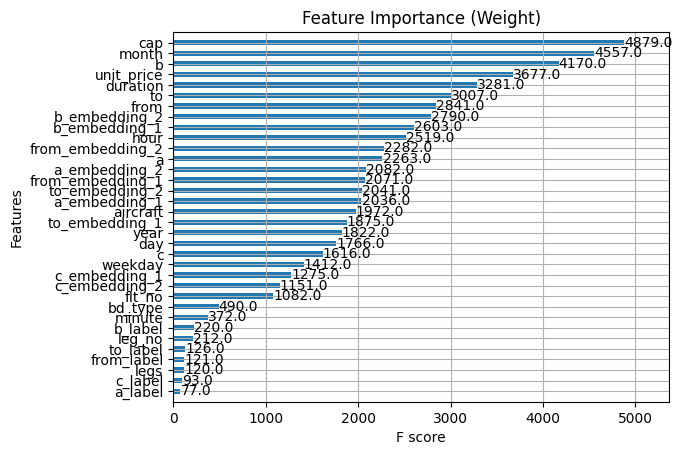

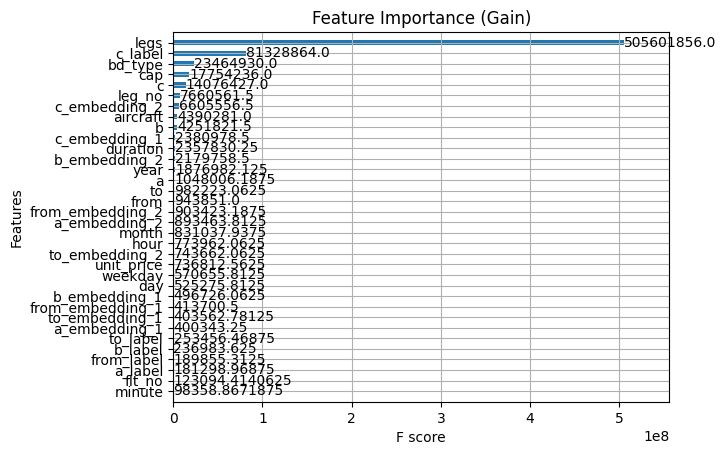

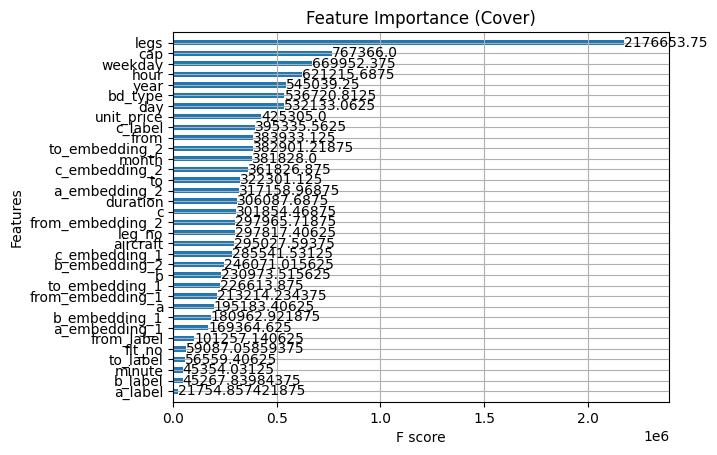

In [16]:
import xgboost as xgb
import matplotlib.pyplot as plt

# 假设 model 是训练好的 XGBoost 模型
xgb.plot_importance(model, importance_type='weight', title="Feature Importance (Weight)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='gain', title="Feature Importance (Gain)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='cover', title="Feature Importance (Cover)", height=0.5)
plt.show()